In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set()
%matplotlib inline

# 0. A teaser about the distribution of p‑values

In [2]:
from scipy.stats import norm

In [7]:
sigma = 1.
mu = 0.0
N = 1000

(array([106., 100.,  89.,  95., 101., 106., 111., 118.,  77.,  97.]),
 array([6.95925516e-04, 1.00577236e-01, 2.00458547e-01, 3.00339858e-01,
        4.00221169e-01, 5.00102479e-01, 5.99983790e-01, 6.99865101e-01,
        7.99746412e-01, 8.99627723e-01, 9.99509033e-01]),
 <BarContainer object of 10 artists>)

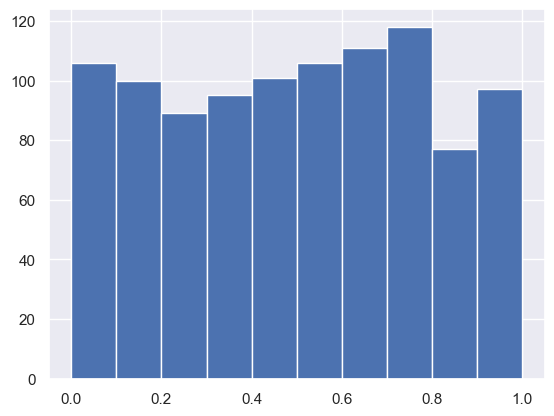

In [8]:
plt.hist([1 - norm(loc=0., scale=sigma / np.sqrt(N)).cdf(mu + np.random.randn(N).mean()) for _ in range(1000)])

# 1. Bonferroni correction  
(Adapted from https://matthew-brett.github.io/teaching/bonferroni_correction.html)

The Bonferroni correction sets a p-value threshold such that the probability of making *at least one* Type I error does not exceed a pre-specified level.

### Family-wise error

We want to find a threshold $\theta$ such that, under the global null hypothesis,

$$
P\big(\exists i:\ \mathrm{p\text{-}value}_i \le \theta\big)=\alpha_{\mathrm{fwe}},
\quad \mathrm{p\text{-}value}_i \in \{\mathrm{p\text{-}value}_i\}_{i=1}^{n}.
$$

### Šidák correction

Let us start with a simpler correction for explanation — the Šidák correction.

The probability that for all $n$ tests the p-values are *greater* than the threshold $\theta$, assuming independence:

$$
P(\mathrm{p\text{-}value}_i > \theta,\ \forall i) = (1 - \theta)^n.
$$

Then the probability that *at least one* p-value satisfies $\mathrm{p\text{-}value} \le \theta$:

$$
P(\exists i:\ \mathrm{p\text{-}value}_i \le \theta) = 1 - (1 - \theta)^n.
$$

Define the family-wise Type I error rate (FWER):

$$
\alpha_{\mathrm{fwe}} = 1 - (1 - \theta)^n.
$$

Solve for $\theta$:

$$
\theta = 1 - (1 - \alpha_{\mathrm{fwe}})^{1/n}.
$$

For example, for $\alpha_{\mathrm{fwe}} = 0.05$:

In [16]:
def sidak_thresh(alpha_fwe, n):
    return 1 - (1 - alpha_fwe)**(1./n)

print(sidak_thresh(0.05, 10))

0.005116196891823743


# Bonferroni correction

The Bonferroni correction is based on **Boole’s inequality** (the union bound), which states that the probability of *at least one* event occurring is at most the sum of the individual probabilities:

$$
P\!\left(\bigcup_{i=1}^{n} A_i\right) \le \sum_{i=1}^{n} P(A_i).
$$

This is easy to see from Venn diagrams.

Let $A_i = \{\mathrm{p\text{-}value}_i \le \theta\}$. Under the null hypothesis, $P(A_i)=\theta$. Therefore,

$$
P\!\left(\exists i:\ \mathrm{p\text{-}value}_i \le \theta\right)
= P\!\left(\bigcup_{i=1}^{n} A_i\right)
\le \sum_{i=1}^{n} P(A_i)
= n\theta.
$$

To ensure $\mathrm{FWER} \le \alpha_{\mathrm{fwe}}$, it is enough to require $n\theta \le \alpha_{\mathrm{fwe}}$, i.e.

$$
\theta \le \frac{\alpha_{\mathrm{fwe}}}{n}.
$$

For example, for $\alpha_{\mathrm{fwe}} = 0.05$ and $n=10$:

$p < 0.05 / \text{(number of tests)}$.

In [18]:
def bonferroni_thresh(alpha_fwe, n):
    return alpha_fwe / n

print(bonferroni_thresh(0.05, 10))

0.005


*The Bonferroni correction does not rely on any independence assumptions.*

This means that Bonferroni remains valid even when the tests are correlated — but it also becomes more conservative (stricter) in such settings.

The Bonferroni threshold

$$
\theta_{\mathrm{Bonferroni}} = \frac{\alpha_{\mathrm{fwe}}}{n}
$$

is always more conservative than the Šidák threshold $\theta_{\mathrm{Šidák}}$ for all $n \ge 1$, although the two are typically close:

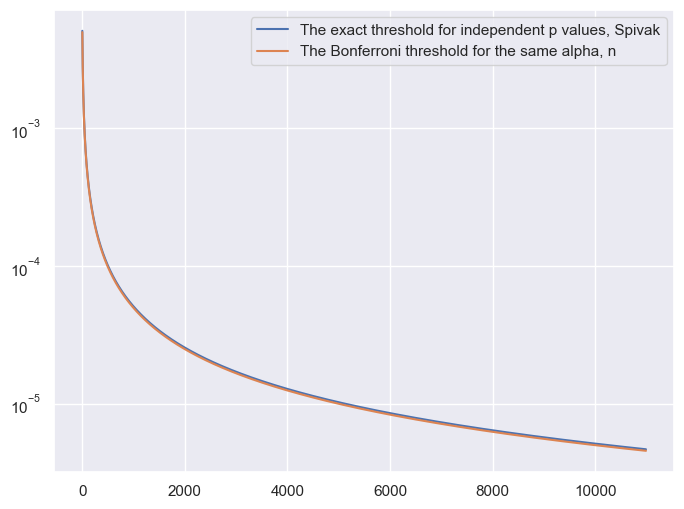

In [23]:
n_tests = np.arange(10, 11000)  # n = 1 through 10

plt.figure(figsize=(8, 6), dpi=100)
plt.plot(sidak_thresh(0.05, n_tests), label="The exact threshold for independent p values, Spivak")
plt.plot(bonferroni_thresh(0.05, n_tests), label="The Bonferroni threshold for the same alpha, n")
plt.yscale('log')
plt.legend()
plt.show()

# 2. FDR  (False Discovery Rate)
(Adapted from https://matthew-brett.github.io/teaching/fdr.html)

FDR (the expected proportion of false rejections) is an alternative way to choose a significance threshold.

In the FDR approach, we control the *expected number of Type I errors*, i.e.

$$
\mathbb{E}(\mathrm{False\ Positives}) \le N\alpha.
$$

Let us look at an example:

In [24]:
N = 100
z_values = np.random.normal(size=N)

Convert Z‑values to p‑values.

In [25]:
import scipy.stats as stats
normal_distribution = stats.norm(loc=0, scale=1.)
# The normal CDF
p_values = normal_distribution.cdf(z_values)

And sort them out:

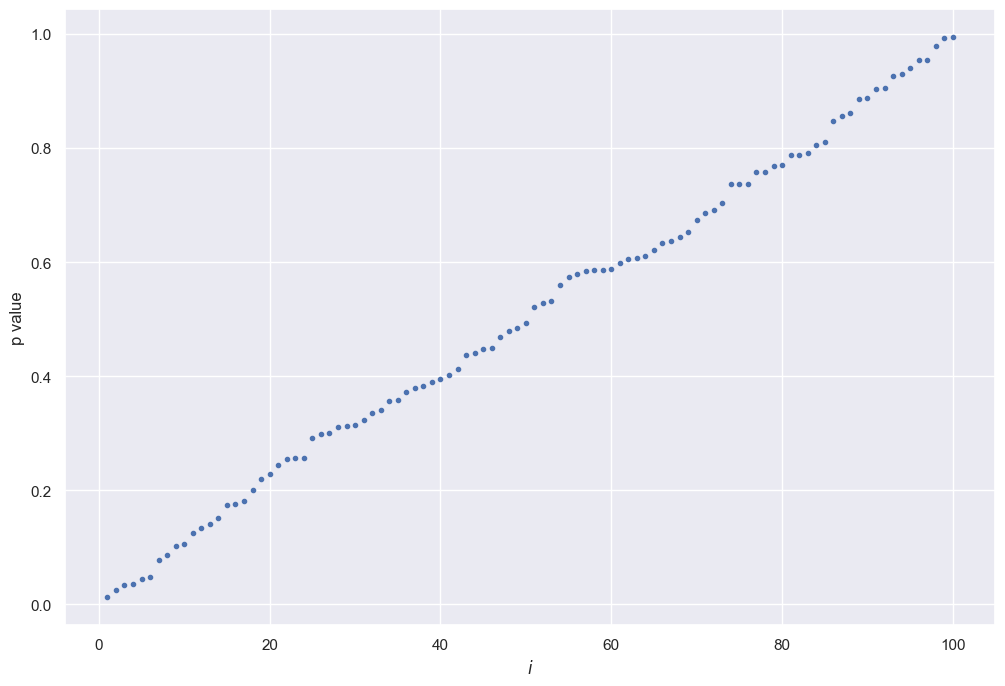

In [26]:
p_values = np.sort(p_values)

plt.figure(figsize=(12, 8), dpi=100)
i = np.arange(1, N + 1) # the 1-based i index of the p values, as in p(i)
plt.plot(i, p_values, '.')
plt.xlabel('$i$')
plt.ylabel('p value')
plt.show()

We want to find a threshold $\theta(i)$ such that only a small fraction of the rejected hypotheses are falsely rejected.

In other words, we want to choose $\theta(i)$ so that

$$
E(\mathrm{FalsePositive}) \,/\, \mathrm{chosen} < \alpha.
$$

Using the Benjamini–Hochberg idea, this leads to the condition

$$
N \frac{p(i)}{i} < \alpha 
\quad\Longrightarrow\quad
p(i) < \alpha \frac{i}{N}.
$$

Fix $\alpha = 0.05$. Let us plot $\alpha \frac{i}{N}$ (red line) together with the sorted $p(i)$ values (blue points):

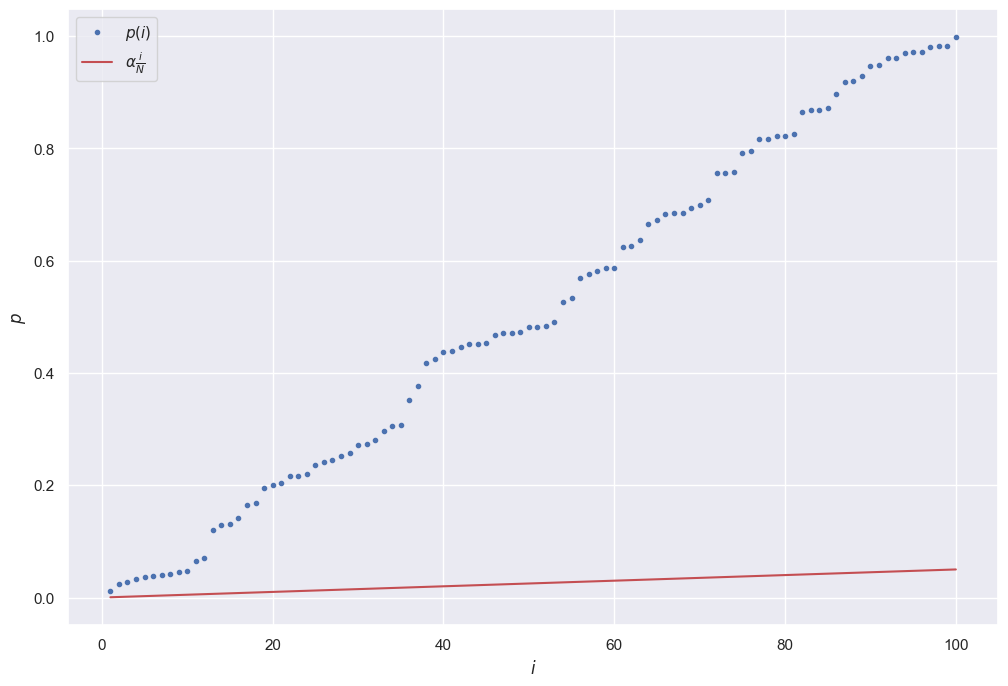

In [14]:
alpha = 0.05
plt.figure(figsize=(12, 8), dpi=100)
plt.plot(i, p_values, 'b.', label='$p(i)$')
plt.plot(i, alpha * i / N, 'r', label=r'$\alpha \frac{i}{N}$')
plt.xlabel(r'$i$')
plt.ylabel(r'$p$')
plt.legend()
plt.show()

Now let's add noise to our measurements.

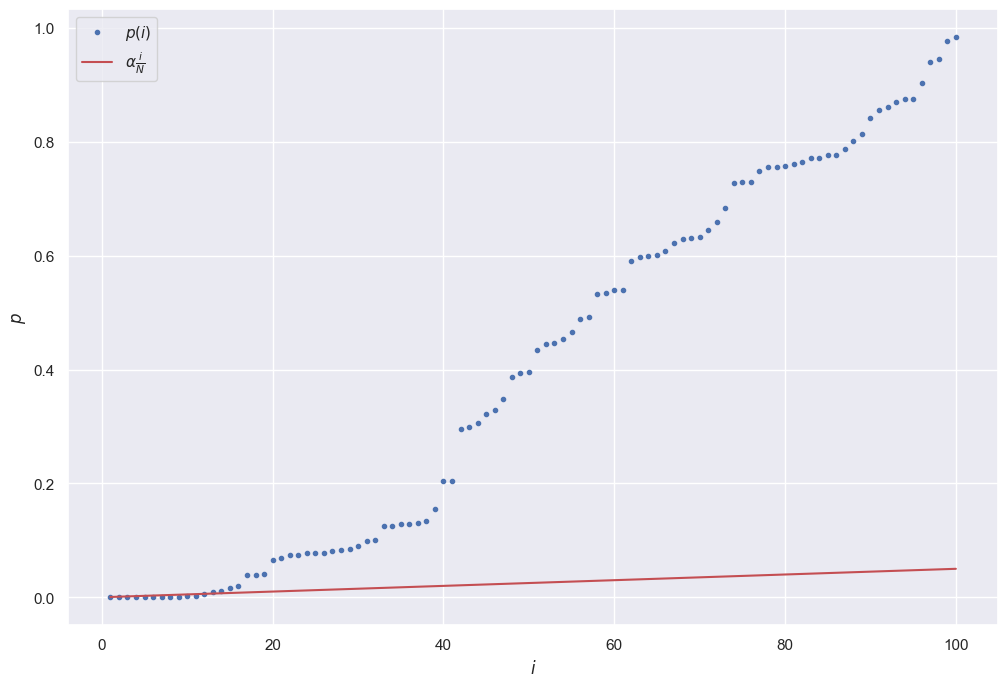

In [15]:
N_signal = 20
N_noise = N - N_signal
noise_z_values = np.random.normal(size=N_noise)
# Add some signal with very low z scores / p values

signal_z_values = np.random.normal(loc=-2.5, size=N_signal)
mixed_z_values = np.sort(np.concatenate((noise_z_values, signal_z_values)))
mixed_p_values = normal_distribution.cdf(mixed_z_values)
plt.figure(figsize=(12, 8), dpi=100)
plt.plot(i, mixed_p_values, 'b.', label='$p(i)$')
plt.plot(i, alpha * i / N, 'r', label=r'$\alpha \frac{i}{N}$')
plt.xlabel('$i$')
plt.ylabel('$p$')
plt.legend()
plt.show()

Let's take a closer look at the beginning of the chart:

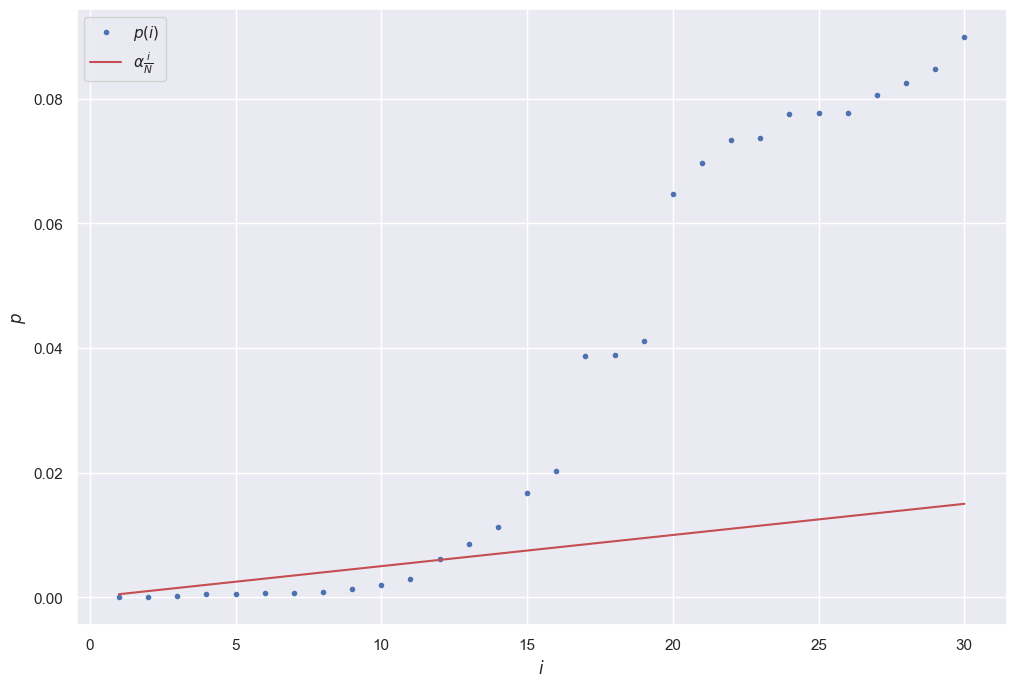

In [16]:
first_i = i[:30]
plt.figure(figsize=(12, 8), dpi=100)
plt.plot(first_i, mixed_p_values[:30], 'b.', label='$p(i)$')
plt.plot(first_i, alpha * first_i / N, 'r', label=r'$\alpha \frac{i}{N}$')
plt.xlabel('$i$')
plt.ylabel('$p$')
plt.legend()

In [17]:
below = mixed_p_values < (alpha * i / N) # True where p(i)<alphai/N
max_below = np.max(np.where(below)[0]) # Max Python array index where p(i)<qi/N
print('p_i:', mixed_p_values[max_below])
print('i:', max_below + 1)

p_i: 0.002865740117037236
i: 11


# 3. Choosing the best machine learning model

## Let's write our own proofreader with Bonferroni and FDR

In [15]:
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold
from collections import defaultdict
from tqdm import tqdm
from sklearn.feature_selection import f_regression, chi2
from statsmodels.stats import multitest
import warnings
warnings.filterwarnings("ignore")

https://www.kaggle.com/c/DrugActivityPrediction

```
The goal of this competition is to allow you to develop predictive models that can determine given a particular compound whether it is active (1) or not (0). As such, the goal would be develop the best binary classification model.

A molecule can be represented by 100000 binary features which represent their topological shapes and other characteristics important for binding.
```

In [7]:
#Read the input files and read every line
from tqdm import tqdm_notebook as tqdm
def loadData(trainingFile):
    
    def convertDataframe(inputFile):
        data = pd.DataFrame(columns=range(100000))
        
        for i in tqdm(range(len(inputFile))):
            record = np.fromstring(inputFile[i], dtype=int, sep=' ')
            record_bool = [0 for j in range(100000)]
            for col in record:
                record_bool[col-1] = 1
            
            data.loc[i] = record_bool
            
        return data
    
    with open(trainingFile, "r") as fr1:
        trainFile = fr1.readlines()
    
    #Split each line in the two files into label and data  
    train_data_list = []
    train_labels_list = []
    
    for inputData in trainFile:
        train_labels_list.append(inputData[0])
        
        #Remove the activity label (0/1) and new line character from each record
        inputData = inputData.replace("0\t", "")
        inputData = inputData.replace("1\t", "")
        inputData = inputData.replace("\n", "")
        train_data_list.append(inputData)
    
    train_labels = np.asarray(train_labels_list)
    train_data = convertDataframe(train_data_list)  
            
    return train_data.values.astype(float), train_labels.astype(float)

In [8]:
X, y = loadData('./train.dat')

C:\Users\Khaled\AppData\Local\Temp\ipykernel_22340\3582536381.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(range(len(inputFile))):


  0%|          | 0/800 [00:00<?, ?it/s]

#### Mini‑reference on the distribution of the correlation coefficient

$$
\mathrm{Cov}(x, y) = \sum_i (x_i - \bar{x})(y_i - \bar{y})
$$

$$
\mathrm{corr}(x, y) = \frac{\mathrm{Cov}(x, y)}{\sigma_x \sigma_y}
$$

$$
(\mathrm{len}(y) - 2)\,\frac{\mathrm{corr}^2(x, y)}{1 - \mathrm{corr}^2(x, y)}
\;\sim\;
F\bigl(1,\ \mathrm{len}(y) - 2\bigr)
$$

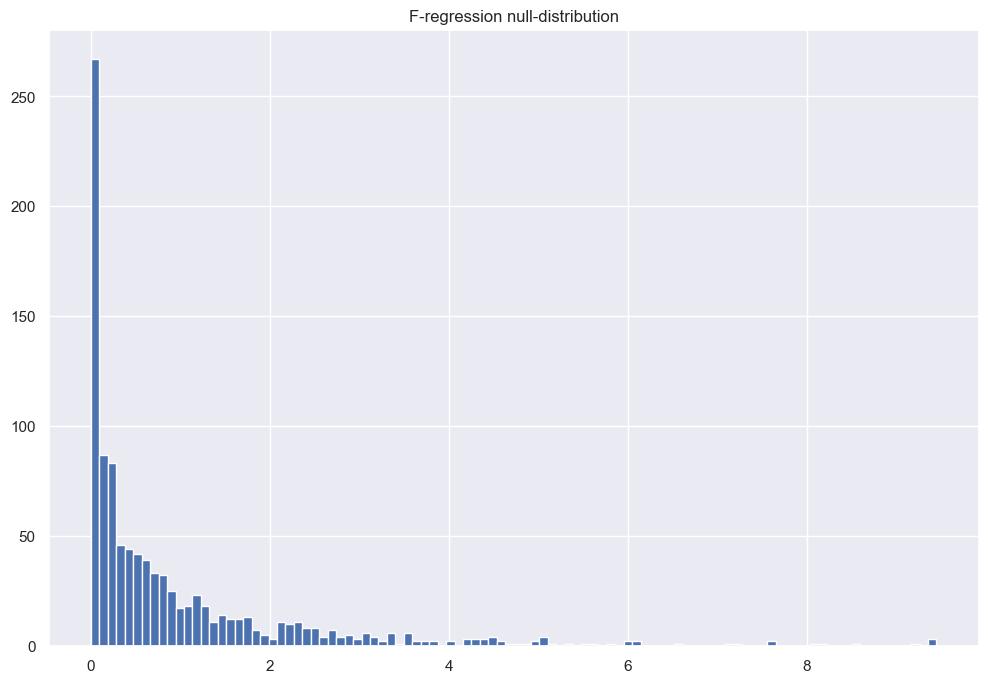

In [4]:
n_f = 100
corrs_f = []
for _ in range(1000):
    x_f = np.random.randn(n_f)
    y_f = np.random.randn(n_f)
    corr = np.corrcoef(x_f, y_f)[0, 1]
    corrs_f.append(corr)
corrs_f = np.array(corrs_f)
plt.figure(figsize=(12, 8))
plt.title('F-regression null-distribution')
plt.hist((n_f - 2) * corrs_f**2 / (1 - corrs_f**2), bins=100);
plt.show()

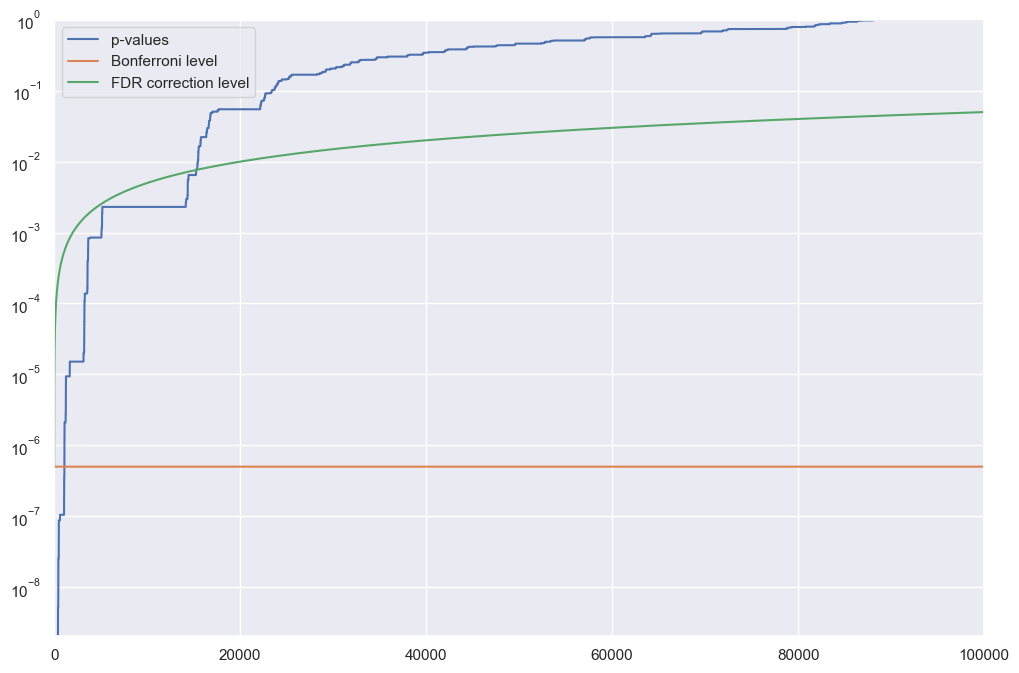

In [9]:
from sklearn.feature_selection import f_regression

_, pvals = f_regression(X=X, y=y)
alpha = 0.05

plt.figure(figsize=(12, 8))

plt.plot(np.arange(len(pvals)), np.sort(pvals), label='p-values')
plt.plot(np.arange(len(pvals)), len(pvals) * [alpha / len(pvals)], label='Bonferroni level')
plt.plot(np.arange(len(pvals)), np.arange(1, len(pvals) + 1) * alpha / len(pvals), label='FDR correction level')
plt.legend()
plt.yscale('log')
plt.xlim(0, 100000)
plt.ylim(np.exp(-20), np.exp(0))
plt.show()

In [10]:
class FTestCorrector:
    def __init__(self, alpha=0.1, method='bonferroni'):
        self.alpha = alpha
        self.mask = None
        self.method = method
        
    def fit(self, X, y):
        from sklearn.feature_selection import f_regression
        _, pvals = f_regression(X=X, y=y)
        if self.method == 'bonferroni':
            self.mask = pvals <= self.alpha / X.shape[1]
        elif self.method == 'fdr':
            self.mask, *_ = multitest.multipletests(pvals, alpha=self.alpha, method='fdr_bh')
        else:
            ValueError('No such method')
        return self
        
    def transform(self, X):
        return X[:, self.mask]

In [16]:
lr = LogisticRegression(solver='liblinear')

ftcorr = FTestCorrector(method='bonferroni', alpha=0.1)
pline = Pipeline([('ftest', ftcorr), ('lr', lr)])

In [17]:
cross_val_score(
    estimator=pline, X=X,
    y=y, cv=StratifiedKFold(n_splits=5, shuffle=True), 
    scoring="roc_auc").mean()

np.float64(0.8932917863984674)

In [18]:
ftcorr = FTestCorrector(method='fdr', alpha=0.1)
pline = Pipeline([('ftest', ftcorr), ('lr', lr)])

In [19]:
cross_val_score(
    estimator=pline, X=X,
    y=y, cv=StratifiedKFold(n_splits=5, shuffle=True), 
    scoring="roc_auc"
).mean()

np.float64(0.9469479166666666)

In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import warnings
warnings.filterwarnings("ignore")

models = {
    'LogisticRegression': LogisticRegression(),
    'GaussianNB': GaussianNB(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'XGBClassifier': GradientBoostingClassifier()
}

In [21]:
# Будем классифицировать по отдельным людям и по 12 сессиям отдельно.
cv = 10
alpha = 0.01
methods = ['bonferroni', 'fdr']


scores = defaultdict(lambda: defaultdict(float))
for model in models:
    for method in methods:
        print("Processing %s %s" % (model, method))
        ftcorr = FTestCorrector(method=method, alpha=alpha)
        pline = Pipeline([('ftest', ftcorr), (model, models[model])])
        scores[model][method] = cross_val_score(estimator=pline, X=X,
                                                y=y, cv=StratifiedKFold(n_splits=cv, shuffle=True), scoring="roc_auc")

Processing LogisticRegression bonferroni
Processing LogisticRegression fdr
Processing GaussianNB bonferroni
Processing GaussianNB fdr
Processing KNeighborsClassifier bonferroni
Processing KNeighborsClassifier fdr
Processing XGBClassifier bonferroni
Processing XGBClassifier fdr


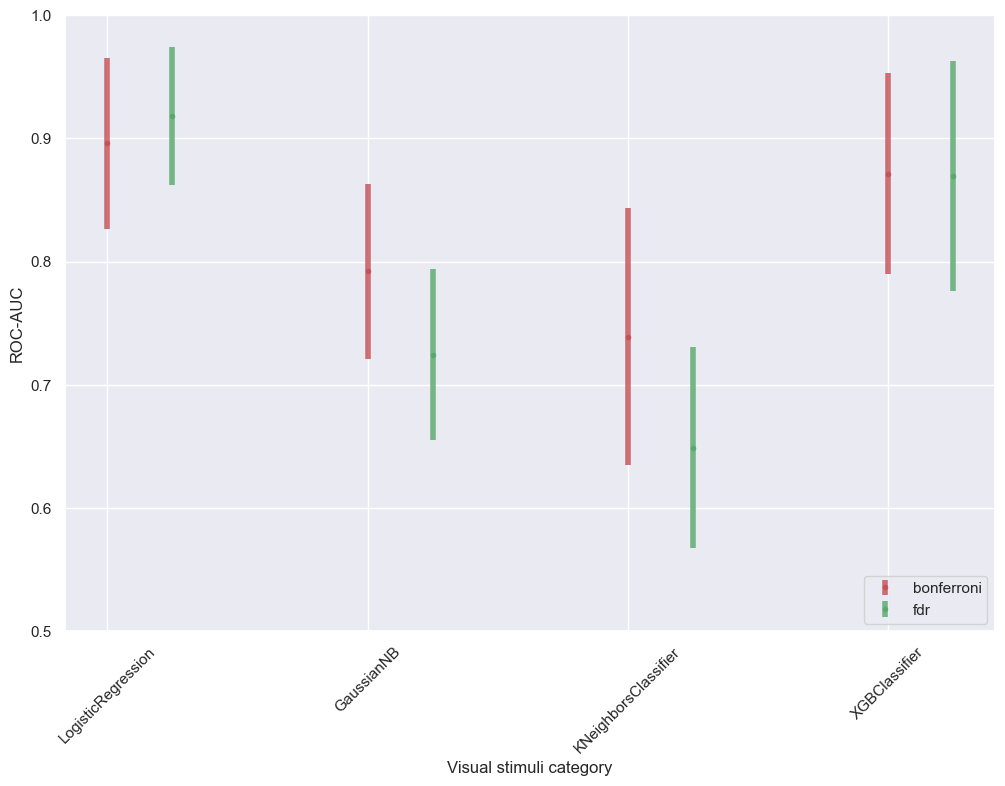

In [22]:
plt.figure(figsize=(12, 8))

tick_position = np.arange(len(models))
plt.xticks(tick_position, models.keys(), rotation=45)

for color, method in zip('rg', methods):
    score_means = [scores[model][method].mean() for model in models]
    score_stds = [scores[model][method].std() for model in models]
    plt.errorbar(tick_position, score_means, yerr=score_stds, fmt='.', lw=4, alpha=0.8, label=method, 
                 color=color)
    tick_position = tick_position + .25

plt.ylabel('ROC-AUC')
plt.xlabel('Visual stimuli category')
plt.ylim(0.5, 1.)
plt.legend(loc='lower right')
plt.show()